# Homogeneous Circle

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import torch as tn

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import gmres
from ttnte.cad import Patch
from ttnte.cad.surfaces import circle
from ttnte.sources import IsotropicInternalSource

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Source": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        }
    }
)

In [3]:
rc = 5 # Critical radius (cm)
patch = Patch(circle(rc), "Source")

# Create mesh
mesh = IGAMesh()
mesh.add_patch(patch)

# Add uniform source of 1/cm to patch
source = IsotropicInternalSource(np.ones((1, *patch.shape)))
patch.set_source(source)

# Refine mesh resolution
mesh.refine(factor=13, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Source, source=IsotropicInternalSource, id=0, name=None, shape=(16, 16), backend=geomdl)

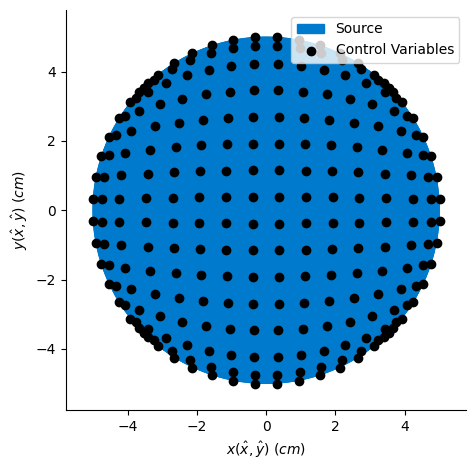

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/circle.png", dpi=300, transparent=True)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-5, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, q, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 34.72 s)
Step            Shape                     Compression
H               1048576,1048576             13252.15
S               1048576,1048576           15775821.11
q               1048576                         1.00
B_out           1048576,1048576            393608.13
Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 12.63 s)
Step            Ranks                     Compression
H               3,3,3,21                  27498790.21
S               1,1,1,7                   194672738.63
B_out           4,66,58,33                 234502.25


## Solve

In [6]:
# Run fixed source calculation
psi = gmres(
    A=(tts.H - tts.S + mats.B_out).round(1e-5),
    b=mats.q,
    tol=1e-6,
    maxiter=1000,
    restart=100,
    gpu_idx=0,
)[0].reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running batched GMRES on GPU 0


-- (1): |r| = 0.225692917377, |r|/|b| = 0.000602091010, Elapsed Time = 0.611 s


-- (2): |r| = 0.028027654425, |r|/|b| = 0.000074770617, Elapsed Time = 1.194 s


-- (3): |r| = 0.007386363629, |r|/|b| = 0.000019704930, Elapsed Time = 1.778 s


-- (4): |r| = 0.002271364499, |r|/|b| = 0.000006059420, Elapsed Time = 2.361 s


-- (5): |r| = 0.000843372269, |r|/|b| = 0.000002249902, Elapsed Time = 2.942 s


-- (6): |r| = 0.000405202636, |r|/|b| = 0.000001080977, Elapsed Time = 3.526 s


-- (7): |r| = 0.000225846797, |r|/|b| = 0.000000602502, Elapsed Time = 4.109 s


-- Converged!


## Plot and Compare to OpenMC

<Figure size 640x480 with 0 Axes>

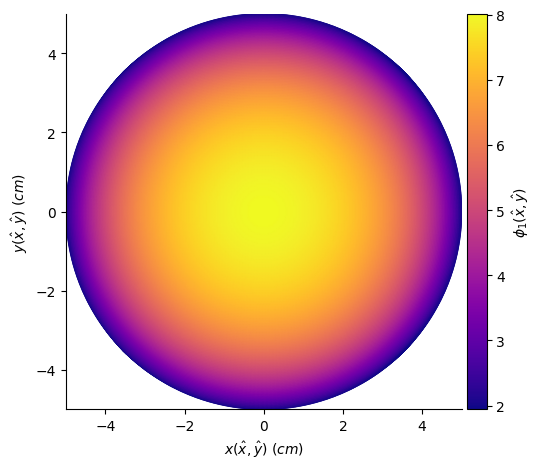

In [7]:
# Set flux
mesh.set_phi(phi)

# Plot
plt.clf()
ax, cbar = mesh.plot(plot_ctrlpts=False)
cbar.set_label("$\\phi_1(\\hat{x}, \\hat{y})$")
plt.tight_layout()
plt.savefig("./figs/phi_1.png", dpi=300, transparent=True)
plt.show()

In [8]:
leakage_frac_openmc = [0.43995423399999983, 2.2245143201699137e-05]

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = float(leakage / production)
print(f"TIDG leakage fraction = {leakage_frac}")
print(f"OpenMC leakage fraction = {leakage_frac_openmc[0]} +/- {leakage_frac_openmc[1]}")
print(f"Difference = {leakage_frac - leakage_frac_openmc[0]}")
print(f"TIDG is {(leakage_frac - leakage_frac_openmc[0]) / leakage_frac_openmc[1]} stdevs from OpenMC")

TIDG leakage fraction = 0.439963760577574
OpenMC leakage fraction = 0.43995423399999983 +/- 2.2245143201699137e-05
Difference = 9.526577574192618e-06
TIDG is 0.42825427050813303 stdevs from OpenMC
